# Do the Hello World example on a 2-qubit Bell state

## Step 1: Map the problem to circuits & operators

In [15]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli

import matplotlib.pyplot as plt

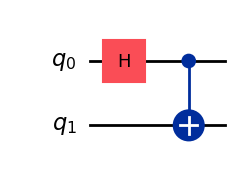

In [16]:
# Map problem to circuit:
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

qc.draw("mpl")

**Multiple-qb (ZZ, HX) operators (ops) should have non-zero expectation values (EVs) & single-qb (IX or HI) ops will have 0 EVs on |phi+>

In [17]:
# Map problem to operators:

ZZ = Pauli("ZZ")
ZI = Pauli("ZI")
IZ = Pauli("IZ")

XX = Pauli("XX")
XI = Pauli("XI")
IX = Pauli("IX")

observables = [ZZ, ZI, IZ, XX, XI, IX]

## Step 2: Optimize the circuit's observables

## Step 3: Execute on the backend

In [18]:
from qiskit_aer.primitives import Estimator

# estimator = Estimator(approximation=True) --> To get the exact values.
estimator = Estimator()

job = estimator.run([qc] * len(observables), observables)

job.result()

EstimatorResult(values=array([1.        , 0.01757812, 0.01757812, 1.        , 0.00585938,
       0.00585938]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0029176, 'sample_measure_time': 0.0011736, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 16264, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 4, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9996910095214844, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0029176, 'sample_measure_time': 0.0011736, 'i

## Step 4: Post-processing (& plotting)

Not much p-p to do, Estimator handled it automatically.

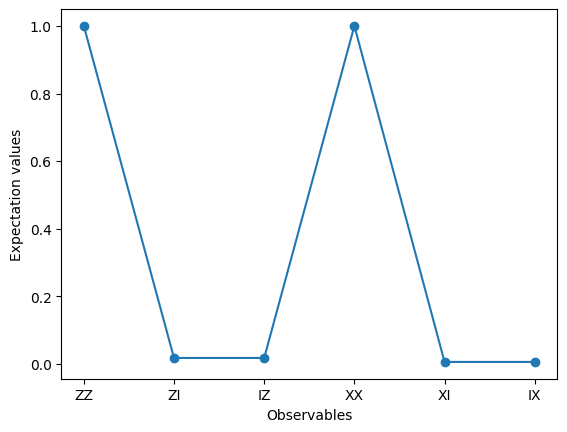

In [20]:
# Plot the EVs for a 2-qb entangled state:
data = ["ZZ", "ZI", "IZ", "XX", "XI", "IX"]
values = job.result().values

plt.plot(data, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Expectation values")
plt.show()